In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import numpy as np
data = pd.read_csv('../../data/Housing.csv')

print(data.size)

X1 = data['area'].values
X2 = data['bedrooms'].values
X3 = data['bathrooms'].values
X4 = data['age'].values

y = data['price'].values


X1_train, X1_test, X2_train, X2_test, X3_train, X3_test, X4_train, X4_test, y_train, y_test = train_test_split(
    X1, X2, X3, X4, y, test_size=0.1, random_state=42
)
def normalize(arr):
    return arr / arr.max() 
    # return (arr - arr.min()) / (arr.max() - arr.min())
  

# NORMAILZE
X1_train = normalize(X1_train)
X1_test = normalize(X1_test)

X2_train = normalize(X2_train)
X2_test = normalize(X2_test)

X3_train = normalize(X3_train)
X3_test = normalize(X3_test)

X4_train = normalize(X4_train)
X4_test = normalize(X4_test)

y_train = normalize(y_train)
y_test = normalize(y_test)

print(X1_train[:5])
print(X1_test[:5])

print(X2_train[:5])
print(X2_test[:5])

print(X3_train[:5])
print(X3_test[:5])

print(X4_train[:5])
print(X4_test[:5])

print(y_train[:5])
print(y_test[:5])


94981
[0.35787157 0.9029806  0.57011402 0.12562513 0.10182036]
[0.72080913 0.49789706 0.15141198 0.43601041 0.5607851 ]
[0.5        1.         0.66666667 0.33333333 0.66666667]
[0.83333333 0.66666667 0.16666667 1.         0.83333333]
[0.5  0.75 0.25 0.25 0.5 ]
[0.75 1.   0.75 1.   0.25]
[0.35897436 0.05128205 0.23076923 0.58974359 0.82051282]
[0.74358974 0.38461538 0.58974359 0.23076923 0.05128205]
[0.35736465 0.85789685 0.55525503 0.10270462 0.15837836]
[0.72624004 0.52481871 0.104501   0.415078   0.5572136 ]


In [5]:
features = np.array((X1_train , X2_train**2 , X3_train**3 , X4_train**4 , np.ones(len(X1_train)))).T
print(features.shape)

parameters = np.array([0, 0 , 0 , 0 , 0])
print(parameters.shape)
print(features)

(4499, 5)
(5,)
[[3.57871574e-01 2.50000000e-01 1.25000000e-01 1.66055672e-02
  1.00000000e+00]
 [9.02980596e-01 1.00000000e+00 4.21875000e-01 6.91610463e-06
  1.00000000e+00]
 [5.70114023e-01 4.44444444e-01 1.56250000e-02 2.83603515e-03
  1.00000000e+00]
 ...
 [6.60332066e-01 6.94444444e-01 4.21875000e-01 0.00000000e+00
  1.00000000e+00]
 [7.69553911e-01 1.00000000e+00 1.56250000e-02 1.23456790e-02
  1.00000000e+00]
 [2.96859372e-01 2.50000000e-01 1.00000000e+00 2.65689075e-01
  1.00000000e+00]]


In [18]:
from sklearn.metrics import r2_score
learning_rate = 0.1
epochs = 1000
losses = []
start_time = time.perf_counter()
for i in range(epochs):
    y_pred = np.dot(features , parameters)
    n = len(X1_train)

    loss = np.mean((y_train - y_pred) ** 2)

    losses.append(loss)
    gradient = (2/n) * np.dot(features.T, (y_pred - y_train))
    
    parameters = parameters - (learning_rate * gradient)

end_time = time.perf_counter()
print(f"Loop execution time: {end_time - start_time:.6f} seconds")
loss = np.mean((y_train - y_pred) ** 2)
y_pred = np.dot(features , parameters)
print(loss)
print(parameters)
print("R2 Score:", r2_score(y_train, y_pred))


Loop execution time: 0.133185 seconds
0.0006211230463436399
[ 1.16921264e-01  5.04691438e-01  4.63937455e-03 -9.11168311e-03
 -5.26210198e-02  2.72236200e-01  1.31431032e-01  1.45946841e-01
  9.89005374e-02 -8.04034192e-03 -1.03158557e-02 -1.71525488e-02
 -2.19516764e-02 -2.47916053e-02 -2.52268043e-02  7.02483623e-02
  1.78036431e-02  1.98517487e-02  1.13536321e-02  3.68947605e-02
  1.42785251e-02  9.39593059e-03  3.98847600e-02  1.43989876e-02
  3.42549126e-02 -6.13408186e-03 -1.60609708e-03  3.29407565e-04
 -8.16419998e-04 -3.08571844e-03 -2.63975195e-03 -1.09859111e-02
 -1.95272904e-03 -4.40643194e-03 -7.89656653e-03 -5.69048706e-02
 -7.00503550e-02 -7.76291568e-02 -5.96803708e-02 -3.83472859e-02
 -5.01268467e-02 -3.66955750e-02 -4.93242868e-02 -3.82835420e-02
 -2.41000453e-02  6.40559981e-03 -1.34651645e-02 -9.93230729e-03
 -1.54487712e-02 -1.44386255e-02 -7.00741879e-03  6.02559353e-03
 -5.99817438e-03 -6.00963617e-03  1.15319248e-02 -2.95453057e-03
  5.66989553e-03  8.60170744e-

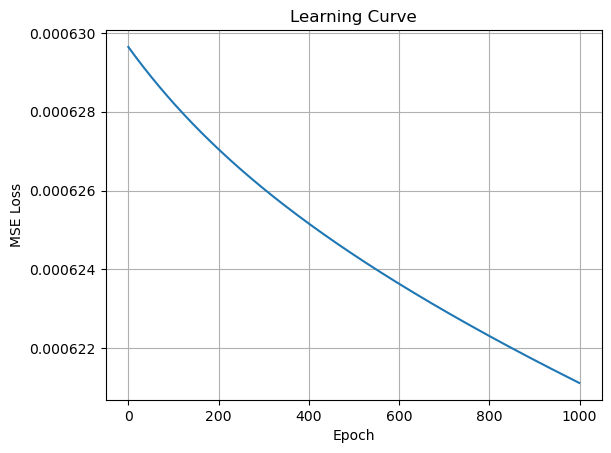

In [19]:
# learning curve Epochs vs Loss

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

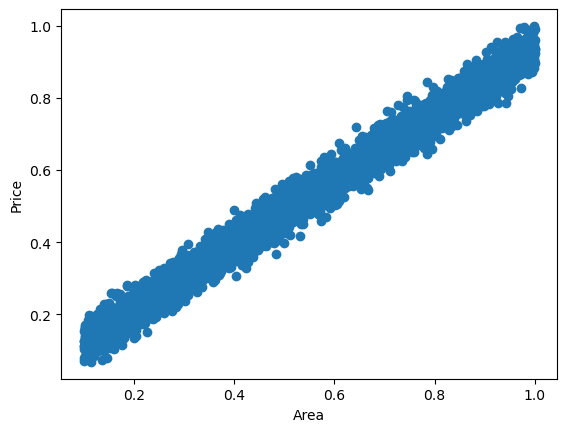

In [20]:
plt.scatter(X1_train, y_train)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

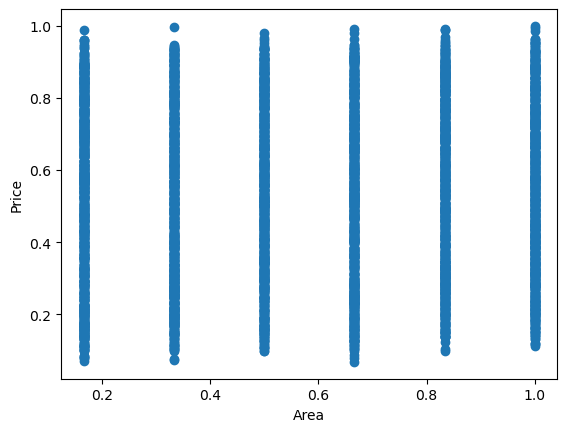

In [11]:
plt.scatter(X2_train, y_train)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

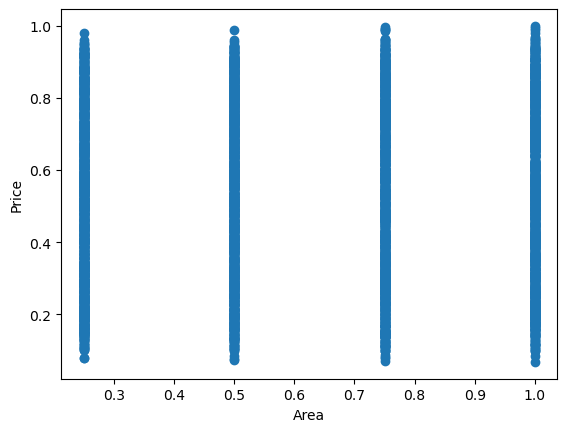

In [12]:
plt.scatter(X3_train, y_train)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

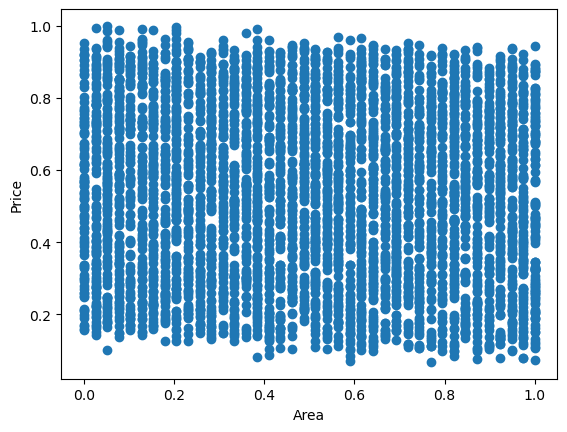

In [21]:
plt.scatter(X4_train, y_train)
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()